<a href="https://colab.research.google.com/github/riack16/Proyecto-rendimiento-acad-mico/blob/main/S100_Equipo4_ParteI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (4, 2), "figure.dpi": 80,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 9})

df = pd.read_csv("https://raw.githubusercontent.com/riack16/Proyecto-rendimiento-acad-mico/main/StudentPerformanceFactors.csv")


print("Filas y columnas:", df.shape)

Filas y columnas: (6607, 20)


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6605 non-null   float64
 1   Attendance                  6605 non-null   float64
 2   Parental_Involvement        6606 non-null   object 
 3   Access_to_Resources         6605 non-null   object 
 4   Extracurricular_Activities  6605 non-null   object 
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6606 non-null   object 
 8   Internet_Access             6606 non-null   object 
 9   Tutoring_Sessions           6606 non-null   float64
 10  Family_Income               6606 non-null   object 
 11  Teacher_Quality             6528 non-null   object 
 12  School_Type                 6605 non-null   object 
 13  Peer_Influence              6606 

In [29]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,Low,High,No,7,73,Low,Yes,0.0,Low,Medium,Public,Positive,3.0,No,High School,Near,Male,67.0
1,19.0,64.0,Low,Medium,No,8,59,Low,Yes,NaN,Medium,Medium,Public,Negative,4.0,No,College,Moderate,Female,61.0
2,24.0,98.0,Medium,Medium,Yes,7,91,Medium,Yes,2.0,Medium,Medium,Public,Neutral,4.0,No,Postgraduate,Near,Male,74.0
3,29.0,89.0,Low,Medium,Yes,8,98,Medium,Yes,1.0,Medium,Medium,Public,Negative,4.0,No,High School,Moderate,Male,71.0
4,19.0,92.0,Medium,Medium,Yes,6,65,Medium,Yes,3.0,Medium,High,Public,Neutral,4.0,No,College,Near,Female,70.0


In [30]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6605.000000,6605.000000,6607.00000,6607.000000,6606.000000,6604.000000,6605.000000
mean,19.973808,79.948978,7.02906,75.070531,1.493642,2.967293,67.215291
std,5.995209,11.736506,1.46812,14.399784,1.230648,1.031015,4.217186
min,0.000000,-91.000000,4.00000,50.000000,0.000000,0.000000,-65.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [31]:
fuera_rango = df[ (df['Exam_Score'] < 0) | (df['Exam_Score'] > 100) | (df['Attendance'] < 0) ]

resumen = pd.DataFrame({
    'Tipo': df.dtypes,
    'Filas_Totales': len(df),
    'Nulos': df.isnull().sum(),
}
)
resumen['Media'] =  round( df.select_dtypes(include='number').mean() , 1)
resumen['Mediana']= round( df.select_dtypes(include='number').median() , 1)
resumen['Minimo'] = round( df.select_dtypes(include='number').min(), 1)
resumen['Maximo'] = round( df.select_dtypes(include='number').max(),1)
resumen ['%_Falta'] = round( resumen ['Nulos'] / resumen['Filas_Totales'] * 100, 2)
Resumenf = resumen.drop(columns=['Filas_Totales','Nulos'])
pd.set_option('display.expand_frame_repr', False)
print(Resumenf)

print('╔══════════════════════════════════════════════════════╗')
print('║           RESUMEN DE DE DATOS                        ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Total de filas originales            : {len(df):>6}       ║')
print(f'║  Total de Columnas originales         : {len(df.columns):>6}       ║')
print(f'║  Valores nulos                        : {df.isnull().sum().sum():>6}       ║')
print(f'║  Valores inconsistentes               : {len(fuera_rango):>6}       ║')
print(f'║  Valores duplicados                   : {len(df[df.duplicated()]):>6}       ║')

print('╚══════════════════════════════════════════════════════╝')

                               Tipo  Media  Mediana  Minimo  Maximo  %_Falta
Hours_Studied               float64   20.0     20.0     0.0    44.0     0.03
Attendance                  float64   79.9     80.0   -91.0   100.0     0.03
Parental_Involvement         object    NaN      NaN     NaN     NaN     0.02
Access_to_Resources          object    NaN      NaN     NaN     NaN     0.03
Extracurricular_Activities   object    NaN      NaN     NaN     NaN     0.03
Sleep_Hours                   int64    7.0      7.0     4.0    10.0     0.00
Previous_Scores               int64   75.1     75.0    50.0   100.0     0.00
Motivation_Level             object    NaN      NaN     NaN     NaN     0.02
Internet_Access              object    NaN      NaN     NaN     NaN     0.02
Tutoring_Sessions           float64    1.5      1.0     0.0     8.0     0.02
Family_Income                object    NaN      NaN     NaN     NaN     0.02
Teacher_Quality              object    NaN      NaN     NaN     NaN     1.20

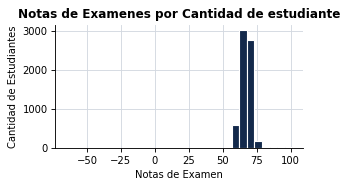

In [32]:
plt.hist(df["Exam_Score"], bins=30, color=AZUL, edgecolor="white")
plt.xlabel("Notas de Examen")
plt.ylabel("Cantidad de Estudiantes")
plt.title("Notas de Examenes por Cantidad de estudiante")
plt.show()

**1. Limpieza y preparación de datos**

- 1 Eliminar Valores fuera de rango: Attendance tiene valores negativos (mínimo -91) y Exam_Score tiene valores fuera de [0,100] (min -65, max 101). Para Attendance asumimos que el signo negativo es un error de captura y tomamos el valor absoluto (recuperamos el dato en vez de perderlo). Para Exam_Score no hay una corrección obvia, así que lo tratamos como dato faltante y lo imputamos más adelante.

In [33]:
# --- Corrección de valores fuera de rango ---
df['Attendance'] = df['Attendance'].abs()
df.loc[df['Attendance'] > 100, 'Attendance'] = np.nan

df.loc[(df['Exam_Score'] < 0) | (df['Exam_Score'] > 100), 'Exam_Score'] = np.nan

print("Nulos en Attendance tras la corrección:", df['Attendance'].isna().sum())
print("Nulos en Exam_Score tras la corrección:", df['Exam_Score'].isna().sum())


Nulos en Attendance tras la corrección: 2
Nulos en Exam_Score tras la corrección: 4


**1.2 Valores faltantes.** Los nulos en columnas numéricas se rellenan con la mediana de
esa columna (es la menos sensible a valores muy grandes o muy chicos). Los nulos en
columnas de texto/categoría se rellenan con la categoría más común (la moda).

*Nota para el reporte final:* esto también rellena los 4 casos en los que `Exam_Score`
(la nota que queremos predecir) quedó vacía. Rellenar la variable objetivo con la mediana
es una simplificación — para el reporte del 23 pueden discutir si prefieren eliminar esas
filas en vez de inventarles una nota "promedio". Con solo 4 filas de 6.607 el efecto en
el modelo es mínimo, pero vale la pena mencionarlo como una decisión tomada a propósito.


In [34]:
df_clean = df.copy()

num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
            'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
cat_cols = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',
            'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality',
            'School_Type', 'Peer_Influence', 'Learning_Disabilities',
            'Parental_Education_Level', 'Distance_from_Home', 'Gender']

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Nulos restantes en todo el dataset:", df_clean.isnull().sum().sum())


Nulos restantes en todo el dataset: 0


**1.3 Codificación.** Varias categóricas tienen un orden natural (`Low < Medium < High`,
etc.), así que en vez de `OneHotEncoder` (que trataría "Alto" y "Bajo" como categorías
sueltas, sin relación entre sí) se codifican como enteros ordinales — 0, 1, 2 — para
conservar esa información de orden y sin inflar la cantidad de columnas. Las binarias
(`Yes/No`, `Male/Female`, etc.) se mapean directamente a 0/1. Los modelos de scikit-learn
(Regresión Lineal, y los que se agreguen después) solo aceptan números como entrada, así
que esta conversión es obligatoria antes de modelar.


In [35]:
# --- Codificación de variables categóricas ---
map_low_med_high = {'Low': 0, 'Medium': 1, 'High': 2}
ordinal_maps = {
    'Parental_Involvement': map_low_med_high,
    'Access_to_Resources': map_low_med_high,
    'Motivation_Level': map_low_med_high,
    'Family_Income': map_low_med_high,
    'Teacher_Quality': map_low_med_high,
    'Peer_Influence': {'Negative': 0, 'Neutral': 1, 'Positive': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Distance_from_Home': {'Near': 0, 'Moderate': 1, 'Far': 2},
}
for col, mapping in ordinal_maps.items():
    df_clean[col] = df_clean[col].map(mapping)

binary_maps = {
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Internet_Access': {'No': 0, 'Yes': 1},
    'School_Type': {'Public': 0, 'Private': 1},
    'Learning_Disabilities': {'No': 0, 'Yes': 1},
    'Gender': {'Male': 0, 'Female': 1},
}
for col, mapping in binary_maps.items():
    df_clean[col] = df_clean[col].map(mapping)

# Por si alguna categoría nueva/mal escrita no quedó mapeada, imputamos con la moda
df_clean[list(ordinal_maps) + list(binary_maps)] = (
    df_clean[list(ordinal_maps) + list(binary_maps)]
    .apply(lambda s: s.fillna(s.mode()[0]))
)

print(df_clean.dtypes.value_counts())
df_clean.head()


int64      15
float64     5
Name: count, dtype: int64


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,0,2,0,7,73,0,1,0.0,0,1,0,2,3.0,0,0,0,0,67.0
1,19.0,64.0,0,1,0,8,59,0,1,1.0,1,1,0,0,4.0,0,1,1,1,61.0
2,24.0,98.0,1,1,1,7,91,1,1,2.0,1,1,0,1,4.0,0,2,0,0,74.0
3,29.0,89.0,0,1,1,8,98,1,1,1.0,1,1,0,0,4.0,0,0,1,0,71.0
4,19.0,92.0,1,1,1,6,65,1,1,3.0,1,2,0,1,4.0,0,1,0,1,70.0


## 2. Análisis exploratorio de datos (EDA)

*(También de Danny: relación de las horas de estudio y del involucramiento parental con
la nota, ya sobre los datos limpios.)*


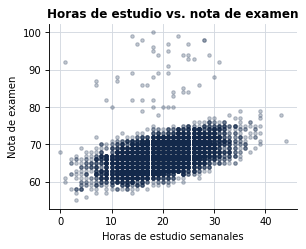

In [36]:
plt.figure(figsize=(4, 3))
plt.scatter(df_clean['Hours_Studied'], df_clean['Exam_Score'], alpha=0.25, color=AZUL, s=10)
plt.xlabel('Horas de estudio semanales')
plt.ylabel('Nota de examen')
plt.title('Horas de estudio vs. nota de examen')
plt.show()




Horas de estudio vs. nota La tendencia es clara: mientras más estudias, mejor te va… pero no es una garantía. El gráfico muestra que con pocas horas (menos de 10) casi nadie supera los 80 puntos. Sin embargo, incluso quienes estudian mucho (25 a 40 horas) a veces terminan con notas bajas, en el rango de 60–70. En otras palabras, estudiar ayuda, pero no explica todo: hay otros factores que influyen en el desempeño, lo cual tiene sentido porque el dataset incluye muchas más variables además de las horas de estudio.

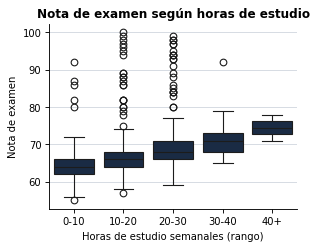

In [37]:
# Agrupamos las horas de estudio en rangos para poder graficarlas como boxplot
bins = [0, 10, 20, 30, 40, df_clean['Hours_Studied'].max()]
labels = ['0-10', '10-20', '20-30', '30-40', '40+']
df_clean['Hours_Studied_bin'] = pd.cut(df_clean['Hours_Studied'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(4, 3))
sns.boxplot(data=df_clean, x='Hours_Studied_bin', y='Exam_Score', color=AZUL)
plt.xlabel('Horas de estudio semanales (rango)')
plt.ylabel('Nota de examen')
plt.title('Nota de examen según horas de estudio')
plt.show()


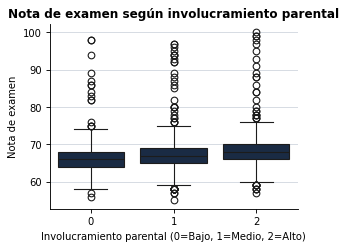

In [38]:
plt.figure(figsize=(4, 3))
sns.boxplot(data=df_clean, x='Parental_Involvement', y='Exam_Score', color=AZUL)
plt.xlabel('Involucramiento parental (0=Bajo, 1=Medio, 2=Alto)')
plt.ylabel('Nota de examen')
plt.title('Nota de examen según involucramiento parental')
plt.show()


Aquí se ve un efecto leve: a medida que el apoyo de los padres pasa de bajo a alto, la mediana de las notas sube un poco y el rango superior llega más cerca del 100. Sin embargo, las tres categorías se solapan bastante, lo que indica que el impacto existe pero no es tan fuerte. Es más un empujón que un cambio radical.

In [39]:
# Tabla de estadísticos descriptivos de las variables numéricas ya limpias
df_clean[num_cols].describe().round(2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.97,79.98,7.03,75.07,1.49,2.97,67.23
std,5.99,11.55,1.47,14.40,1.23,1.03,3.87
min,0.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,100.00


**Entrenamiento y Prueba**

In [40]:
X = df_clean.drop(columns=["Exam_Score", "Hours_Studied_bin"])
y = df_clean["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Filas para entrenar:", X_train.shape[0])
print("Filas para probar:", X_test.shape[0])


Filas para entrenar: 5285
Filas para probar: 1322


**4. baseline: predecir siempre el promedio**

In [41]:
promedio_train = y_train.mean()
pred_baseline_train = np.full(shape=y_train.shape, fill_value=promedio_train)
pred_baseline_test = np.full(shape=y_test.shape, fill_value=promedio_train)


**5. Regresión Lineal**

In [42]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_lr_train = model_lr.predict(X_train)
pred_lr_test = model_lr.predict(X_test)


**6. Paso 7 — comparar baseline vs. Regresión Lineal (entrenamiento y prueba)**

In [43]:
resultados = pd.DataFrame({
    "Modelo": ["Baseline (promedio)", "Regresion Lineal"],
    "RMSE_train": [
        np.sqrt(mean_squared_error(y_train, pred_baseline_train)),
        np.sqrt(mean_squared_error(y_train, pred_lr_train)),
    ],
    "RMSE_test": [
        np.sqrt(mean_squared_error(y_test, pred_baseline_test)),
        np.sqrt(mean_squared_error(y_test, pred_lr_test)),
    ],
    "MAE_train": [
        mean_absolute_error(y_train, pred_baseline_train),
        mean_absolute_error(y_train, pred_lr_train),
    ],
    "MAE_test": [
        mean_absolute_error(y_test, pred_baseline_test),
        mean_absolute_error(y_test, pred_lr_test),
    ],
    "R2_train": [
        r2_score(y_train, pred_baseline_train),
        r2_score(y_train, pred_lr_train),
    ],
    "R2_test": [
        r2_score(y_test, pred_baseline_test),
        r2_score(y_test, pred_lr_test),
    ],
})
resultados


,Modelo,RMSE_train,RMSE_test,MAE_train,MAE_test,R2_train,R2_test
0,Baseline (promedio),3.894207,3.759321,2.845421,2.818786,0.000000,-0.000821
1,Regresion Lineal,2.057236,1.803762,0.489362,0.449130,0.720919,0.769593


**7. Paso 8 — gráfica: nota real vs. nota predicha**

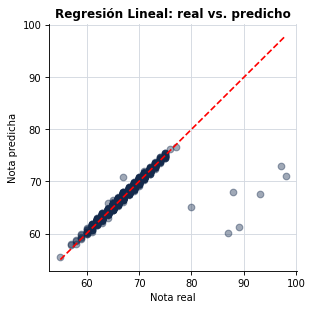

In [44]:
plt.figure(figsize=(4,4))
plt.scatter(y_test, pred_lr_test, alpha=0.4, color="#13294B")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Nota real")
plt.ylabel("Nota predicha")
plt.title("Regresión Lineal: real vs. predicho")
plt.show()
